# **IMPORTING NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **READING DATASET**

In [2]:
df = pd.read_csv('TITANIC.csv') 

# **DISPLAYING TABLE STRUCTURE USING HEAD**

In [3]:
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **UNDERSTANDING THE DATA & CHECKING MISSING VALUES**

In [4]:
# 1. Dataset mein total kitni rows aur columns hain
print("Dataset size (Rows, Columns):", df.shape)
print("-" * 50)

# 2. Dataset ki basic information aur data types (kaunsa text hai, kaunsa number)
print("\nDataset information:")
df.info()
print("-" * 50)

# 3. Har column mein kitni missing (null) values hain
print("\nMissing Values :")
print(df.isnull().sum())
print("-" * 50)

# 4. Numerical columns ka statistical summary (mean, min, max etc.)
print("\nStatistical Summary:")
display(df.describe())

Dataset size (Rows, Columns): (891, 12)
--------------------------------------------------

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
--------------------------------------------------

Missing Values :
PassengerId      0
Survived         0
Pclass           0
Name             0
S

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **HANDLING MISSING VALUES (DATA CLEANING)**

In [5]:
# 1. 'Cabin' column mein bohot zyada missing values hoti hain, isliye hum isko poora drop (delete) kar denge
df = df.drop(columns=['Cabin'])

# 2. 'Age' (umar) wale column mein jo values missing hain, unko hum 'Median' (beech ki value) age se bhar denge
df['Age'] = df['Age'].fillna(df['Age'].median())

# 3. 'Embarked' (kahan se board kiya) mein sirf 1-2 values missing hoti hain, usko hum 'Mode' (jo sabse zyada baar aaya hai) se bhar denge
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 4. Clean karne ke baad wapas check karte hain ki kya abhi bhi koi missing value bachi hai?
print("AFTER CLEANING :\n")
print(df.isnull().sum())

AFTER CLEANING :

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# **EXPLORATORY DATA ANALYSIS (DATA VISUALIZATION)*

/tmp/ipykernel_1027/278770935.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set1')


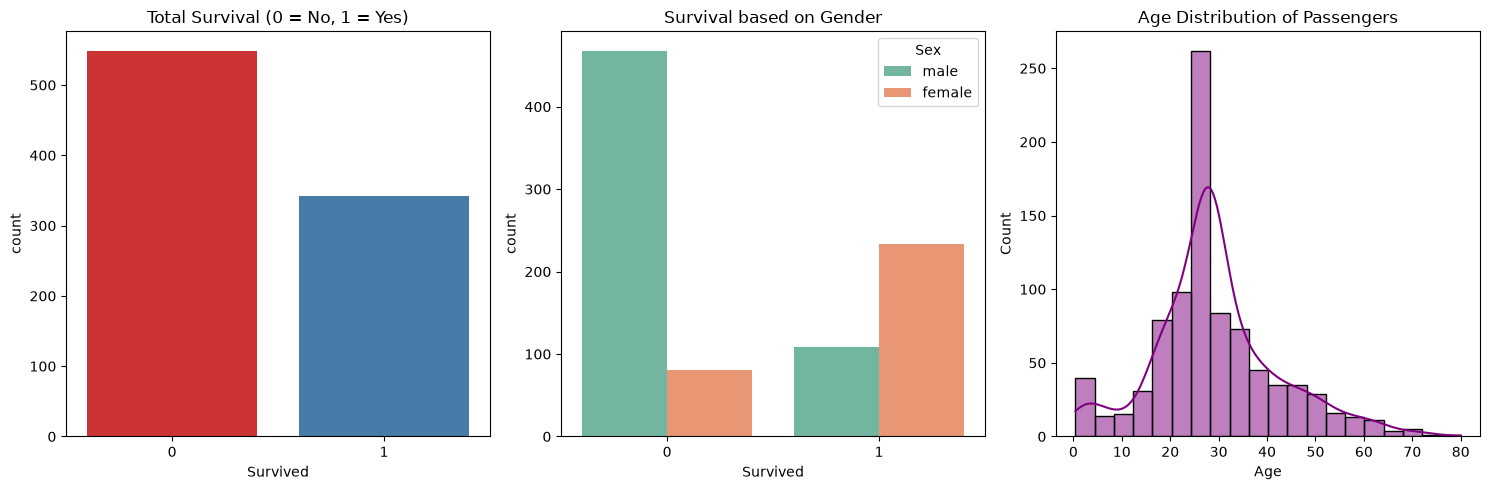

In [6]:
# Graphs ka size set kar rahe hain
plt.figure(figsize=(15, 5))

# Graph 1: Kitne log bache (1) aur kitne nahi (0)
plt.subplot(1, 3, 1)
sns.countplot(x='Survived', data=df, palette='Set1')
plt.title('Total Survival (0 = No, 1 = Yes)')

# Graph 2: Male vs Female Survival
plt.subplot(1, 3, 2)
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set2')
plt.title('Survival based on Gender')

# Graph 3: Passengers ki Age (Umar) ka distribution
plt.subplot(1, 3, 3)
sns.histplot(df['Age'], bins=20, kde=True, color='purple')
plt.title('Age Distribution of Passengers')

# Graphs ko theek se dikhane ke liye
plt.tight_layout()
plt.show()

# **DATA PREPROCESSING (TEXT TO NUMBERS & DROPPING COLUMNS)**

In [7]:
# 1. Jo columns ML model ke kaam ke nahi hain unhe hata dete hain
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
df = df.drop(columns=columns_to_drop)

# 2. Text data ko numbers mein convert karna
# 'Sex' column: male = 0, female = 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 'Embarked' column: Isme 3 categories hain (S, C, Q), iske hum naye columns bana lenge (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Clean aur ML-ready data dekhte hain
print("Machine Learning model ke liye final ready data:\n")
display(df.head())

Machine Learning model ke liye final ready data:



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


# **UNDERSTANDING RELATIONSHIPS (CORRELATION HEATMAP)**

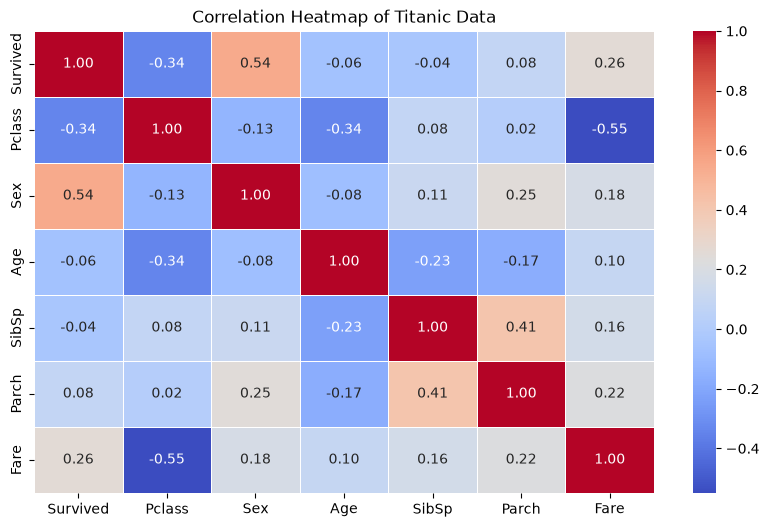

In [10]:
# Sirf numerical columns ko select karein correlation ke liye
numerical_df = df.select_dtypes(include=['number'])

# Correlation matrix calculate karein
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Data')
plt.show()

# **FINAL INSIGHTS (WHAT THE DATA TELLS US)**

After cleaning the data and visualizing the relationships, we can clearly see the survival patterns on the Titanic without even training a Machine Learning model:

1. **Gender Rule ("Women and Children First"):** Females had a significantly higher chance of survival compared to males.
2. **Wealth Rule (Class Matters):** Passengers in 1st Class (expensive tickets) were more than twice as likely to survive as those in 3rd Class. (Approx. 63% survival in 1st Class vs. 24% in 3rd Class).
3. **Family Rule:** Passengers traveling completely alone (without siblings, spouses, or parents) had lower survival chances compared to those traveling with family members.

**Conclusion:** A Machine Learning Model (like Logistic Regression or Random Forest) simply learns these exact mathematical patterns from the historical data so that it can accurately predict whether a new passenger would survive or not!